# Rainfall RNN LSTM Project

**Project Title:** Rainfall Prediction Using Specialized RNN -> LSTM

**Author:** Mark William Gichora

**Unit Name:** Neural Networks; CAT Individual Assignment

**Date:** 2026

**Task:** Task 1 , Section 2 - Implementation of a machine learning algorithm (RNN) using one or more of TensorFlow, ScikitLearn of Kerras.

**Description:** 
This project implements a specialized form of Recurrent Neural Networks (RNN), Long Short-Term Memory (LSTM) models to predict rainfall patterns using historical climate data from Kenya (1991-2016). The model analyzes temporal sequences in rainfall data to forecast future precipitation, utilizing deep learning techniques for time series forecasting.

In [1]:
import os
import random
import warnings

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import callbacks, layers, models, optimizers

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

CLASS_NAMES = {
    0: "Below-normal anomaly",
    1: "Normal",
    2: "Above-normal anomaly",
}


In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "kenya-climate-data-1991-2016-rainfallmm.csv"
raw_df = pd.read_csv(DATA_PATH)
raw_df.head()


,Year,Month Average,Rainfall - (MM)
0,1991,Jan Average,38.2847
1,1991,Feb Average,12.7492
2,1991,Mar Average,73.3656
3,1991,Apr Average,83.1350
4,1991,May Average,112.2750


In [3]:
raw_df.shape


(312, 3)

In [4]:
raw_df.columns


Index(['Year', 'Month Average', 'Rainfall - (MM)'], dtype='str')

In [5]:
raw_df.describe()


,Year,Rainfall - (MM)
count,312.000000,312.000000
mean,2003.500000,54.800805
std,7.512048,39.560441
min,1991.000000,1.157650
25%,1997.000000,25.848200
50%,2003.500000,43.819150
75%,2010.000000,74.958175
max,2016.000000,247.081000


In [6]:
raw_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             312 non-null    int64  
 1   Month Average    312 non-null    str    
 2   Rainfall - (MM)  312 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 7.4 KB


In [7]:
raw_df.isnull().sum()


Year               0
Month Average      0
Rainfall - (MM)    0
dtype: int64

# 5. Data Cleaning and Preparation

The dataset must be cleaned and properly formatted before training the neural network.

The following preprocessing steps are performed:
- handling missing values,
- formatting dates,
- selecting relevant features,
- sorting observations chronologically.

In [8]:
# Convert the monthly labels to real datetimes and keep a clean modeling frame.
month_names = raw_df["Month Average"].astype(str).str.extract(r"([A-Za-z]+)", expand=False)

df = raw_df.copy()
df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" + month_names + "-01")
df["Rainfall_mm"] = pd.to_numeric(df["Rainfall - (MM)"], errors="coerce")

df = df.sort_values("Date").reset_index(drop=True)
df = df.ffill()
df["Month"] = df["Date"].dt.month

df[["Date", "Month", "Rainfall_mm"]].head()


,Date,Month,Rainfall_mm
0,1991-01-01,1,38.2847
1,1991-02-01,2,12.7492
2,1991-03-01,3,73.3656
3,1991-04-01,4,83.1350
4,1991-05-01,5,112.2750


# 6. Exploratory Data Analysis

Visualization helps identify:
- rainfall trends,
- seasonal patterns,
- and unusual fluctuations in the dataset.

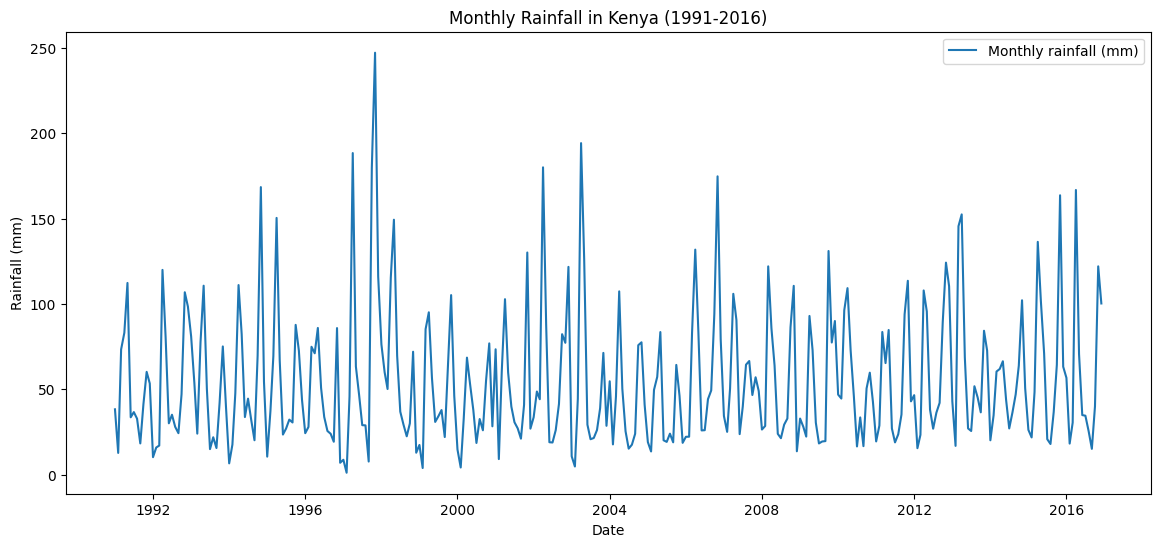

In [9]:
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Rainfall_mm"], label="Monthly rainfall (mm)")
plt.title("Monthly Rainfall in Kenya (1991-2016)")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.show()


# 7. Creating Rainfall Anomaly Classes

There are 2 target is `"monthly_anomaly"`. This compares January with other Januaries, April with other Aprils, and so on. It is the more climate-correct target, but it is much harder with only 26 years of monthly data.

In [10]:
SEQUENCE_LENGTH = 12
TRAIN_FRACTION = 0.80

# Options:
# - "global_tercile": matches the original notebook's low/normal/high rainfall classes.
# - "monthly_anomaly": stricter climatological anomalies by calendar month.
TARGET_MODE = "monthly_anomaly"

target_positions = np.arange(SEQUENCE_LENGTH, len(df))
train_target_count = int(len(target_positions) * TRAIN_FRACTION)
train_target_positions = target_positions[:train_target_count]
test_target_positions = target_positions[train_target_count:]

if TARGET_MODE == "monthly_anomaly":
    monthly_thresholds = (
        df.loc[train_target_positions]
        .groupby("Month")["Rainfall_mm"]
        .quantile([0.33, 0.66])
        .unstack()
        .rename(columns={0.33: "Low_Threshold", 0.66: "High_Threshold"})
    )

    def classify_rainfall(row):
        thresholds = monthly_thresholds.loc[row["Month"]]
        if row["Rainfall_mm"] <= thresholds["Low_Threshold"]:
            return 0
        if row["Rainfall_mm"] >= thresholds["High_Threshold"]:
            return 2
        return 1

    display(monthly_thresholds.round(2))

elif TARGET_MODE == "global_tercile":
    low_threshold, high_threshold = df.loc[train_target_positions, "Rainfall_mm"].quantile([0.33, 0.66])

    def classify_rainfall(row):
        if row["Rainfall_mm"] <= low_threshold:
            return 0
        if row["Rainfall_mm"] >= high_threshold:
            return 2
        return 1

    display(pd.DataFrame({
        "Low_Threshold": [low_threshold],
        "High_Threshold": [high_threshold],
    }, index=["training_global_quantiles"]).round(2))

else:
    raise ValueError("TARGET_MODE must be 'global_tercile' or 'monthly_anomaly'")


df["Rainfall_Class"] = df.apply(classify_rainfall, axis=1).astype(int)

print("Target mode:", TARGET_MODE)
print("Training target dates:", df.loc[train_target_positions[0], "Date"].date(), "to", df.loc[train_target_positions[-1], "Date"].date())
print("Testing target dates:", df.loc[test_target_positions[0], "Date"].date(), "to", df.loc[test_target_positions[-1], "Date"].date())
print("Training target class counts:")
print(df.loc[train_target_positions, "Rainfall_Class"].value_counts().sort_index().rename(index=CLASS_NAMES))
print("\nTesting target class counts:")
print(df.loc[test_target_positions, "Rainfall_Class"].value_counts().sort_index().rename(index=CLASS_NAMES))


,Low_Threshold,High_Threshold
Month,,
1,17.87,33.28
2,16.37,28.31
3,45.84,65.35
4,93.53,113.36
5,68.54,84.17
6,26.24,35.98
7,19.00,29.93
8,25.75,30.71
9,21.36,26.09


Target mode: monthly_anomaly
Training target dates: 1992-01-01 to 2011-12-01
Testing target dates: 2012-01-01 to 2016-12-01
Training target class counts:
Rainfall_Class
Below-normal anomaly    84
Normal                  72
Above-normal anomaly    84
Name: count, dtype: int64

Testing target class counts:
Rainfall_Class
Below-normal anomaly    10
Normal                  20
Above-normal anomaly    30
Name: count, dtype: int64


# Visualize the Classes

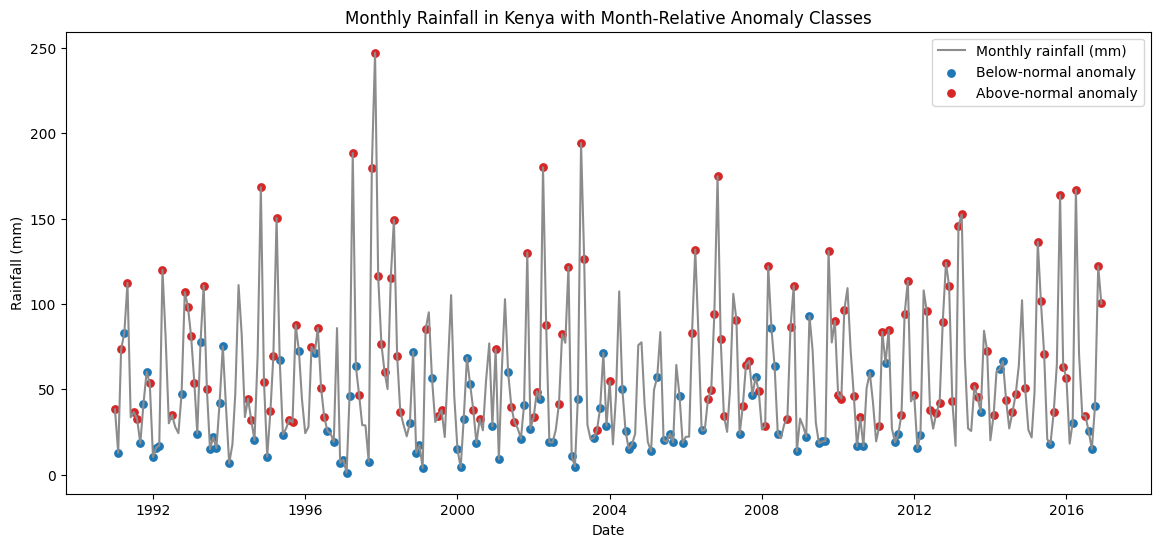

In [11]:
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Rainfall_mm"], color="0.55", label="Monthly rainfall (mm)")

low_points = df[df["Rainfall_Class"] == 0]
high_points = df[df["Rainfall_Class"] == 2]

plt.scatter(low_points["Date"], low_points["Rainfall_mm"], color="tab:blue", label="Below-normal anomaly", s=28)
plt.scatter(high_points["Date"], high_points["Rainfall_mm"], color="tab:red", label="Above-normal anomaly", s=28)
plt.title("Monthly Rainfall in Kenya with Month-Relative Anomaly Classes")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.show()


# 8. Feature Engineering and Scaling

Neural networks perform better when numerical values are normalized.

Rainfall values are scaled between 0 and 1 using MinMaxScaler.


In [12]:
model_df = df.copy()
train_feature_end = train_target_positions[-1]

training_climatology = model_df.loc[:train_feature_end].groupby("Month")["Rainfall_mm"].agg(["mean", "std", "median"])

model_df["Month_Mean_Train"] = model_df["Month"].map(training_climatology["mean"])
model_df["Month_Std_Train"] = model_df["Month"].map(training_climatology["std"]).replace(0, np.nan)
model_df["Rainfall_Anomaly_Z"] = (model_df["Rainfall_mm"] - model_df["Month_Mean_Train"]) / model_df["Month_Std_Train"]
model_df["Rainfall_Ratio"] = model_df["Rainfall_mm"] / model_df["Month_Mean_Train"]

model_df["Rainfall_3MA"] = model_df["Rainfall_mm"].rolling(window=3, min_periods=1).mean()
model_df["Rainfall_6MA"] = model_df["Rainfall_mm"].rolling(window=6, min_periods=1).mean()
model_df["Rainfall_12MA"] = model_df["Rainfall_mm"].rolling(window=12, min_periods=1).mean()
model_df["Rainfall_Diff1"] = model_df["Rainfall_mm"].diff().fillna(0)

model_df["Month_Sin"] = np.sin(2 * np.pi * model_df["Month"] / 12)
model_df["Month_Cos"] = np.cos(2 * np.pi * model_df["Month"] / 12)

feature_cols = [
    "Rainfall_mm",
    "Rainfall_Anomaly_Z",
    "Rainfall_Ratio",
    "Rainfall_3MA",
    "Rainfall_6MA",
    "Rainfall_12MA",
    "Rainfall_Diff1",
    "Month_Sin",
    "Month_Cos",
]

feature_frame = model_df[feature_cols].replace([np.inf, -np.inf], np.nan).ffill().bfill()

scaler = StandardScaler()
scaler.fit(feature_frame.iloc[:train_feature_end].values)
scaled_features = scaler.transform(feature_frame.values)

print("Feature columns:", feature_cols)
print("Rows available after feature engineering:", len(model_df))
print("Rows removed by feature engineering:", len(df) - len(model_df))


Feature columns: ['Rainfall_mm', 'Rainfall_Anomaly_Z', 'Rainfall_Ratio', 'Rainfall_3MA', 'Rainfall_6MA', 'Rainfall_12MA', 'Rainfall_Diff1', 'Month_Sin', 'Month_Cos']
Rows available after feature engineering: 312
Rows removed by feature engineering: 0


# 9. Sequencing

LSTM networks learn from sequences.

The model will use rainfall data from the previous 12 months to predict the rainfall anomaly class of the next month.

In [13]:
X_history = []
X_target_month = []
y = []
sample_dates = []

for target_pos in target_positions:
    X_history.append(scaled_features[target_pos - SEQUENCE_LENGTH:target_pos])
    X_target_month.append(model_df.loc[target_pos, ["Month_Sin", "Month_Cos"]].values)
    y.append(model_df.loc[target_pos, "Rainfall_Class"])
    sample_dates.append(model_df.loc[target_pos, "Date"])

X_history = np.array(X_history, dtype="float32")
X_target_month = np.array(X_target_month, dtype="float32")
y = np.array(y, dtype="int64")
sample_dates = np.array(sample_dates)

print("History input shape:", X_history.shape)
print("Target-month input shape:", X_target_month.shape)
print("Target shape:", y.shape)
print("Sequence length:", SEQUENCE_LENGTH)


History input shape: (300, 12, 9)
Target-month input shape: (300, 2)
Target shape: (300,)
Sequence length: 12


# 10. Train-Test Split

The dataset is divided chronologically into:
- training data,
- validation data,
- and testing data.

In [14]:
X_history_train_full = X_history[:train_target_count]
X_history_test = X_history[train_target_count:]

X_month_train_full = X_target_month[:train_target_count]
X_month_test = X_target_month[train_target_count:]

y_train_full = y[:train_target_count]
y_test = y[train_target_count:]

test_dates = sample_dates[train_target_count:]

val_size = max(24, int(len(X_history_train_full) * 0.15))

X_history_train = X_history_train_full[:-val_size]
X_history_val = X_history_train_full[-val_size:]

X_month_train = X_month_train_full[:-val_size]
X_month_val = X_month_train_full[-val_size:]

y_train = y_train_full[:-val_size]
y_val = y_train_full[-val_size:]

print("Train history shape:", X_history_train.shape)
print("Validation history shape:", X_history_val.shape)
print("Test history shape:", X_history_test.shape)
print("Train class counts:", np.bincount(y_train, minlength=3))
print("Validation class counts:", np.bincount(y_val, minlength=3))
print("Test class counts:", np.bincount(y_test, minlength=3))


Train history shape: (204, 12, 9)
Validation history shape: (36, 12, 9)
Test history shape: (60, 12, 9)
Train class counts: [73 60 71]
Validation class counts: [11 12 13]
Test class counts: [10 20 30]


# 10. Baseline Checks

A model should beat simple non-neural baselines before its accuracy is considered useful. These baselines are especially important.


In [15]:
def evaluate_predictions(name, true_labels, predicted_labels):
    metrics = {
        "model": name,
        "accuracy": accuracy_score(true_labels, predicted_labels),
        "balanced_accuracy": balanced_accuracy_score(true_labels, predicted_labels),
        "macro_f1": f1_score(true_labels, predicted_labels, average="macro", zero_division=0),
    }
    print(f"{name}")
    print(f"  Accuracy:          {metrics['accuracy']:.3f}")
    print(f"  Balanced accuracy: {metrics['balanced_accuracy']:.3f}")
    print(f"  Macro F1:          {metrics['macro_f1']:.3f}")
    print(confusion_matrix(true_labels, predicted_labels))
    return metrics


baseline_results = []

majority_class = np.bincount(y_train_full, minlength=3).argmax()
majority_pred = np.full_like(y_test, majority_class)
baseline_results.append(evaluate_predictions("Majority class", y_test, majority_pred))

persistence_pred = np.array([
    model_df.loc[target_pos - 1, "Rainfall_Class"] for target_pos in test_target_positions
])
baseline_results.append(evaluate_predictions("Previous-month persistence", y_test, persistence_pred))

train_months = np.array([pd.Timestamp(date).month for date in sample_dates[:train_target_count]])
test_months = np.array([pd.Timestamp(date).month for date in sample_dates[train_target_count:]])
month_majority = {
    month: np.bincount(y_train_full[train_months == month], minlength=3).argmax()
    for month in range(1, 13)
}
month_majority_pred = np.array([month_majority[month] for month in test_months])
baseline_results.append(evaluate_predictions("Target-month majority", y_test, month_majority_pred))

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df


Majority class
  Accuracy:          0.167
  Balanced accuracy: 0.333
  Macro F1:          0.095
[[10  0  0]
 [20  0  0]
 [30  0  0]]
Previous-month persistence
  Accuracy:          0.400
  Balanced accuracy: 0.389
  Macro F1:          0.389
[[ 4  3  3]
 [ 2  6 12]
 [ 4 12 14]]
Target-month majority
  Accuracy:          0.167
  Balanced accuracy: 0.333
  Macro F1:          0.095
[[10  0  0]
 [20  0  0]
 [30  0  0]]


,model,accuracy,balanced_accuracy,macro_f1
0,Majority class,0.166667,0.333333,0.095238
1,Previous-month persistence,0.400000,0.388889,0.389086
2,Target-month majority,0.166667,0.333333,0.095238


# 11. Building the LSTM Model

This model uses the previous 12 months as the sequence input and the target month as a known calendar input. Keeping the target month separate helps the model distinguish, for example, a January forecast from an April forecast without leaking the target rainfall amount.


In [16]:
sequence_input = layers.Input(shape=(X_history_train.shape[1], X_history_train.shape[2]), name="history")
target_month_input = layers.Input(shape=(X_month_train.shape[1],), name="target_month")

x = layers.LSTM(64)(sequence_input)
x = layers.Concatenate()([x, target_month_input])
x = layers.Dense(24, activation="relu")(x)
x = layers.Dropout(0.20)(x)
output = layers.Dense(3, activation="softmax")(x)

model = models.Model(inputs=[sequence_input, target_month_input], outputs=output)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ history             │ (None, 12, 9)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     18,944 │ history[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ target_month        │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 66)        │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ target_month[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 24)        │      1,608 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 24)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │         75 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,627 (80.57 KB)

 Trainable params: 20,627 (80.57 KB)

 Non-trainable params: 0 (0.00 B)

# 13. Training the Model

The model is trained using historical rainfall sequences.

In [17]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

training_callbacks = [
    callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-5),
]

history = model.fit(
    {"history": X_history_train, "target_month": X_month_train},
    y_train,
    epochs=100,
    batch_size=8,
    validation_data=({"history": X_history_val, "target_month": X_month_val}, y_val),
    callbacks=training_callbacks,
    shuffle=True,
    verbose=0,
)

print("Training epochs run:", len(history.history["loss"]))
print("Best validation accuracy:", round(max(history.history["val_accuracy"]), 3))
print("Best validation loss:", round(min(history.history["val_loss"]), 3))


Training epochs run: 13
Best validation accuracy: 0.306
Best validation loss: 1.128


# 14. Model Performance Visualization

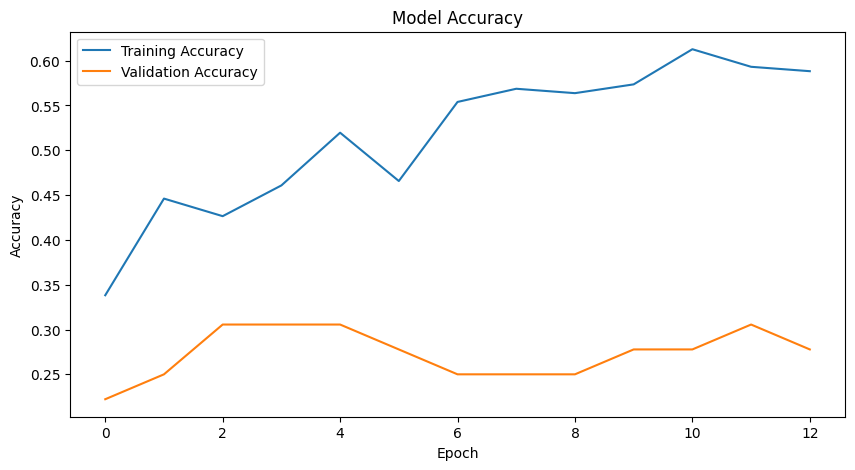

In [18]:
# Plot accuracy
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

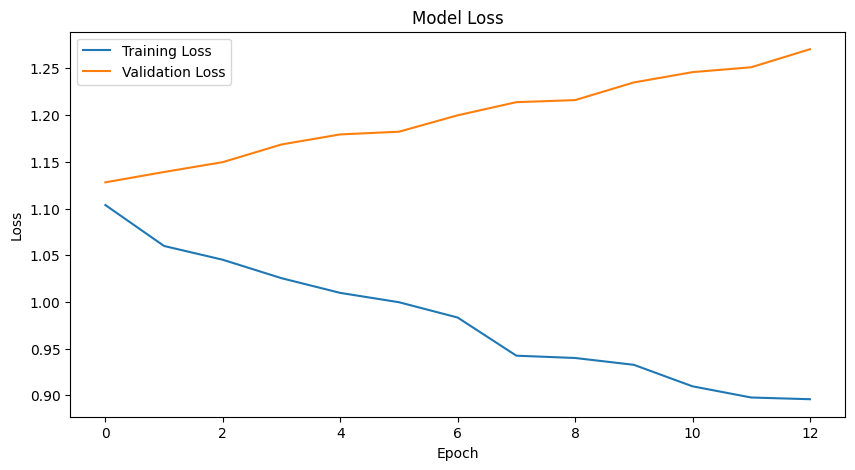

In [19]:
# Plot loss
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

# 15. Model Evaluation

The trained model is evaluated using:
- accuracy,
- confusion matrix,
- and classification metrics.

In [20]:
test_loss, test_accuracy = model.evaluate(
    {"history": X_history_test, "target_month": X_month_test},
    y_test,
    verbose=0,
)

predicted_probabilities = model.predict(
    {"history": X_history_test, "target_month": X_month_test},
    verbose=0,
)
predicted_classes = np.argmax(predicted_probabilities, axis=1)

lstm_metrics = evaluate_predictions("LSTM", y_test, predicted_classes)
print(f"Test loss: {test_loss:.3f}")


LSTM
  Accuracy:          0.367
  Balanced accuracy: 0.400
  Macro F1:          0.284
[[ 7  0  3]
 [11  0  9]
 [15  0 15]]
Test loss: 1.104


In [21]:
print(classification_report(
    y_test,
    predicted_classes,
    target_names=[CLASS_NAMES[i] for i in range(3)],
    zero_division=0,
))


                      precision    recall  f1-score   support

Below-normal anomaly       0.21      0.70      0.33        10
              Normal       0.00      0.00      0.00        20
Above-normal anomaly       0.56      0.50      0.53        30

            accuracy                           0.37        60
           macro avg       0.26      0.40      0.28        60
        weighted avg       0.31      0.37      0.32        60



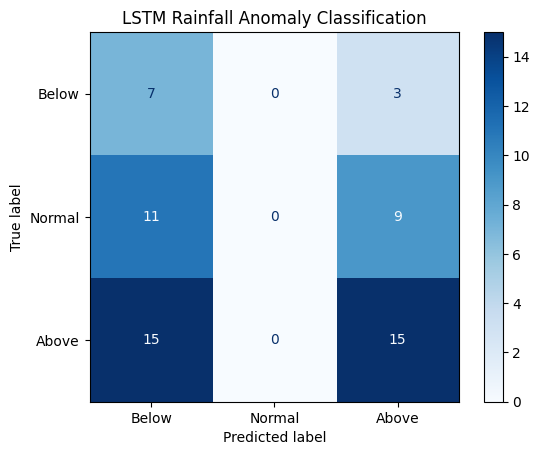

In [22]:
cm = confusion_matrix(y_test, predicted_classes)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Below", "Normal", "Above"],
).plot(cmap="Blues")
plt.title("LSTM Rainfall Anomaly Classification")
plt.show()


# 16. Sample Predictions

This section demonstrates how the model predicts rainfall anomaly classes using unseen data sequences.

In [23]:
sample_index = 0
sample_prediction = predicted_probabilities[sample_index]

print("Date:", pd.Timestamp(test_dates[sample_index]).date())
print("Predicted Class:", CLASS_NAMES[int(np.argmax(sample_prediction))])
print("Actual Class:", CLASS_NAMES[int(y_test[sample_index])])
print("Class Probabilities:", dict(zip(CLASS_NAMES.values(), sample_prediction.round(3))))


Date: 2012-01-01
Predicted Class: Below-normal anomaly
Actual Class: Above-normal anomaly
Class Probabilities: {'Below-normal anomaly': np.float32(0.383), 'Normal': np.float32(0.277), 'Above-normal anomaly': np.float32(0.34)}
